W tym laboratorium porównamy trzy podejścia do przetwarzania tekstu:
1. **Stemming** - regułowe przycinanie końcówek (Snowball PL)
2. **Lematyzacja** - sprowadzenie do formy podstawowej (spaCy / Morfeusz2)
3. **Embeddingi kontekstowe** - reprezentacja wektorowa z modelu HerBERT

Corpus: **Allegro Reviews** – polskie recenzje produktów z etykietą sentymentu

In [ ]:
## Instalacja bibliotek
# Uruchom tę komórkę tylko raz (Colab: wymagany restart po instalacji)
# odkomentuj poniższe linie, aby zainstalować wymagane biblioteki

!pip install datasets transformers sentence-transformers
!pip install nltk spacy scikit-learn matplotlib seaborn pandas
!python -m spacy download pl_core_news_sm
!pip install stempel

/opt/anaconda3/envs/anndl/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 3.1 MB/s  0:00:06m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 2.6 MB/s  0:00:01 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 599.5/599.5 kB 3.0 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━

In [ ]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from collections import Counter
from datasets import load_dataset
import nltk
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize

import spacy
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

print("Wszystkie biblioteki zostały załadowane.")
print(f"PyTorch: {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Urządzenie: {device}")

Wszystkie biblioteki zostały załadowane.
PyTorch: 2.11.0
Urządzenie: cpu


In [ ]:
print("Pobieranie Allegro Reviews...")

dataset = load_dataset("allegro_reviews")
print(dataset)

Pobieranie Allegro Reviews...


DatasetDict({
    train: Dataset({
        features: ['text', 'rating'],
        num_rows: 9577
    })
    test: Dataset({
        features: ['text', 'rating'],
        num_rows: 1006
    })
    validation: Dataset({
        features: ['text', 'rating'],
        num_rows: 1002
    })
})


In [ ]:
df_train = pd.DataFrame(dataset["train"])
df_test  = pd.DataFrame(dataset["test"])

print(f"Zbiór treningowy: {len(df_train)} przykładów")
print(f"Zbiór testowy:    {len(df_test)} przykładów")
print("\nKolumny:", df_train.columns.tolist())
print("\nPierwsze 3 rekordy:")
df_train.head(3)

Zbiór treningowy: 9577 przykładów
Zbiór testowy:    1006 przykładów

Kolumny: ['text', 'rating']

Pierwsze 3 rekordy:


,text,rating
0,Jako do ceny dobra. Przyssawka mogłaby być lep...,3.0
1,Na słuchawkę czekałam spory czas a po zadzwoni...,1.0
2,"Czajnik na pierwszy rzut oka wygląda ok, ale n...",1.0


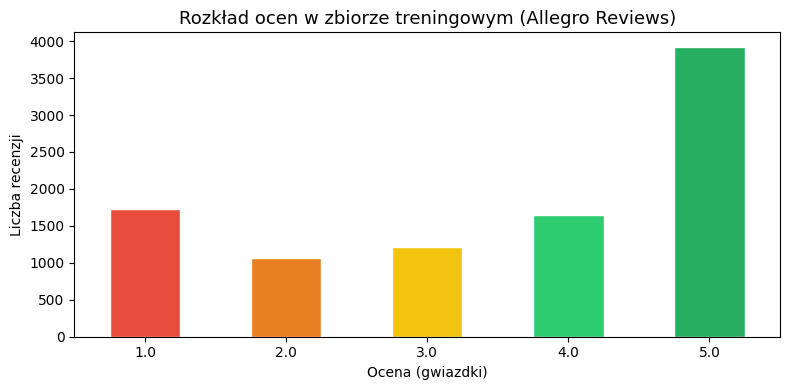

In [ ]:
plt.figure(figsize=(8, 4))
df_train["rating"].value_counts().sort_index().plot(
    kind="bar", color=["#e74c3c","#e67e22","#f1c40f","#2ecc71","#27ae60"],
    edgecolor="white"
)
plt.title("Rozkład ocen w zbiorze treningowym (Allegro Reviews)", fontsize=13)
plt.xlabel("Ocena (gwiazdki)")
plt.ylabel("Liczba recenzji")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=120)
plt.show()

In [ ]:
df_train["sentiment"] = df_train["rating"].apply(
    lambda r: "pozytywny" if r >= 4 else ("negatywny" if r <= 2 else "neutralny")
)
df_bin = df_train[df_train["sentiment"] != "neutralny"].copy()
print(f"Po usunięciu neutralnych: {len(df_bin)} recenzji")
print(df_bin["sentiment"].value_counts())

Po usunięciu neutralnych: 8369 recenzji
sentiment
pozytywny    5567
negatywny    2802
Name: count, dtype: int64


In [ ]:
POLISH_STOPWORDS = set([
    "i", "w", "z", "na", "do", "się", "nie", "to", "że", "a",
    "jest", "jak", "ale", "po", "czy", "przez", "co", "o", "za",
    "też", "już", "tak", "ten", "ta", "te", "go", "mu", "je",
    "mi", "ma", "od", "przy", "dla", "lub", "być", "ze", "tej",
    "jej", "jego", "ich", "się", "by", "bo", "więc", "tylko",
    "jeszcze", "właśnie", "np", "tzw", "wiele", "bardzo", "wszystko"
])

In [ ]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # usuń URL
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", " ", text)  # tylko litery PL
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_basic(text: str) -> list[str]:
    return [t for t in clean_text(text).split() if len(t) > 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [t for t in tokens if t not in POLISH_STOPWORDS]

sample_text = df_bin["text"].iloc[0]
print("Oryginał:", sample_text[:200])
print("\nPo czyszczeniu:", clean_text(sample_text)[:200])
print("\nTokeny:", tokenize_basic(sample_text)[:15])

Oryginał: Na słuchawkę czekałam spory czas a po zadzwonieniu okazało się ,że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mimo to i tak czekałam znowu gdzie bardzo mi była po

Po czyszczeniu: na słuchawkę czekałam spory czas a po zadzwonieniu okazało się że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mimo to i tak czekałam znowu gdzie bardzo mi była pot

Tokeny: ['słuchawkę', 'czekałam', 'spory', 'czas', 'zadzwonieniu', 'okazało', 'się', 'paczka', 'się', 'zawieruszyła', 'ten', 'sam', 'dzień', 'mieli', 'wysłać']


In [ ]:
class PolishStemmer:
    SUFFIXES = sorted([
        'zacja', 'zacji', 'ości', 'owie', 'ania', 'enie', 'ienia',
        'ami', 'ach', 'iem', 'om', 'ie', 'ią', 'ię',
        'ej', 'ym', 'im', 'ów', 'ę', 'ą',
        'a', 'i', 'y', 'e', 'u',
    ], key=len, reverse=True)

    def stem(self, word: str) -> str:
        word = word.lower()
        for suffix in self.SUFFIXES:
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word

stemmer = PolishStemmer()


In [ ]:
stemmer = PolishStemmer()

def stem_text(text: str) -> list[str]:
    tokens = remove_stopwords(tokenize_basic(text))
    return [stemmer.stem(t) for t in tokens]

demo_sentences = [
    "Kupiłem ten produkt dwa tygodnie temu i jestem bardzo zadowolony.",
    "Produkty tej firmy są zawsze wysokiej jakości.",
    "Zamówiłem kilka produktów i wszystkie dotarły na czas.",
]

print("=" * 60)
print("STEMMING — przykłady")
print("=" * 60)
for sent in demo_sentences:
    tokens = tokenize_basic(sent)
    stemmed = [stemmer.stem(t) for t in tokens]
    for orig, stem in zip(tokens, stemmed):
        if orig != stem:
            print(f"  {orig:20s} → {stem}")
    print()

STEMMING — przykłady
  tygodnie             → tygodn
  temu                 → tem
  zadowolony           → zadowolon

  produkty             → produkt
  firmy                → firm
  zawsze               → zawsz
  wysokiej             → wysoki
  jakości              → jak

  kilka                → kilk
  produktów            → produkt
  wszystkie            → wszystk
  dotarły              → dotarł



In [ ]:
print("Przetwarzanie stemmingiem...")

df_bin["stemmed_tokens"] = df_bin["text"].apply(stem_text)
df_bin["stemmed_text"]   = df_bin["stemmed_tokens"].apply(lambda t: " ".join(t))

print("Stemming ukończony.")
print("\nPrzykład:")
print("ORYGINAŁ:", df_bin["text"].iloc[0][:150])
print("STEMMED: ", df_bin["stemmed_text"].iloc[0][:150])

Przetwarzanie stemmingiem...
Stemming ukończony.

Przykład:
ORYGINAŁ: Na słuchawkę czekałam spory czas a po zadzwonieniu okazało się ,że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mi
STEMMED:  słuchawk czekałam spor czas zadzwonieni okazało paczk zawieruszył sam dzień miel wysłać najszybsz kurierem mimo czekałam znow gdz był potrzebn tego ni


In [ ]:
print("Ładowanie modelu spaCy (pl_core_news_sm)...")
nlp = spacy.load("pl_core_news_sm", disable=["parser", "ner"])
print("Model załadowany.")

Ładowanie modelu spaCy (pl_core_news_sm)...
Model załadowany.


In [ ]:
def lemmatize_text(text: str) -> list[str]:
    cleaned = clean_text(text)
    doc = nlp(cleaned)
    lemmas = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2
    ]
    return remove_stopwords(lemmas)

print("\n" + "=" * 60)
print("LEMATYZACJA — przykłady")
print("=" * 60)
for sent in demo_sentences:
    doc = nlp(clean_text(sent))
    for token in doc:
        if token.text != token.lemma_ and len(token.text) > 2:
            print(f"  {token.text:20s} → {token.lemma_:20s}  [{token.pos_}]")
    print()


LEMATYZACJA — przykłady
  kupiłem              → kupić być             [VERB]
  tygodnie             → tydzień               [NOUN]
  jestem               → być                   [AUX]

  produkty             → produkt               [NOUN]
  tej                  → ten                   [DET]
  firmy                → firma                 [NOUN]
  wysokiej             → wysoki                [ADJ]
  jakości              → jakość                [NOUN]

  zamówiłem            → zamówić być           [VERB]
  produktów            → produkt               [NOUN]
  wszystkie            → wszystek              [DET]
  dotarły              → dotrzeć               [VERB]



In [ ]:
print("Przetwarzanie lematyzacją (może potrwać 1-2 min)...")
df_bin["lemma_tokens"] = df_bin["text"].apply(lemmatize_text)
df_bin["lemma_text"]   = df_bin["lemma_tokens"].apply(lambda t: " ".join(t))

print("Lematyzacja ukończona.")

print("\nPrzykład:")
print("ORYGINAŁ:", df_bin["text"].iloc[0][:150])
print("LEMMA:   ", df_bin["lemma_text"].iloc[0][:150])


Przetwarzanie lematyzacją (może potrwać 1-2 min)...
Lematyzacja ukończona.

Przykład:
ORYGINAŁ: Na słuchawkę czekałam spory czas a po zadzwonieniu okazało się ,że paczka im się zawieruszyła i w ten sam dzień mieli wysłać najszybszym kurierem i mi
LEMMA:    słuchawka czekać być spór czas zadzwonienie okazać paczka zawieruszyć dzień mieć wysłać najszybszym kurier czekać być potrzebny niby bateria trzymać d


In [ ]:
comparison_sents = [
    "Kupiłem ten produkt dwa tygodnie temu i jestem bardzo zadowolony z zakupu.",
    "Produkty tej firmy są zawsze doskonałej jakości i polecam je wszystkim.",
    "Zamówienie dotarło szybko, opakowanie było idealne i wszystko działało poprawnie.",
    "Niestety produkt okazał się wadliwy i musiałam go zwrócić do sklepu.",
    "Obsługa klienta była pomocna i rozwiązała mój problem bardzo sprawnie.",
]

rows = []
for sent in comparison_sents:
    tokens_raw   = tokenize_basic(sent)
    tokens_stem  = stem_text(sent)
    tokens_lemma = lemmatize_text(sent)
    rows.append({
        "Oryginał": sent[:60] + "...",
        "Liczba tokenów (raw)":    len(tokens_raw),
        "Liczba tokenów (stem)":   len(tokens_stem),
        "Liczba tokenów (lemma)":  len(tokens_lemma),
        "Stem":  " ".join(tokens_stem[:8]),
        "Lemma": " ".join(tokens_lemma[:8]),
    })

df_compare = pd.DataFrame(rows)
print(df_compare[["Oryginał","Stem","Lemma"]].to_string(index=False))

                                                       Oryginał                                                        Stem                                                          Lemma
Kupiłem ten produkt dwa tygodnie temu i jestem bardzo zadowo...       kupiłem produkt dwa tygodn tem jestem zadowolon zakup                     kupić być produkt tydzień zadowolony zakup
Produkty tej firmy są zawsze doskonałej jakości i polecam je...             produkt firm zawsz doskonał jak polecam wszystk                         produkt firma doskonały jakość polecać
Zamówienie dotarło szybko, opakowanie było idealne i wszystk... zamówi dotarło szybko opakowan było idealn działało poprawn zamówienie dotarło szybko opakowanie idealny działać poprawnie
Niestety produkt okazał się wadliwy i musiałam go zwrócić do...        niestet produkt okazał wadliw musiałam zwrócić sklep       niestety produkt okazać wadliwy musieć być zwrócić sklep
Obsługa klienta była pomocna i rozwiązała mój problem bardzo...  

In [ ]:
vocab_raw   = set(tok for text in df_bin["text"] for tok in tokenize_basic(text))
vocab_stem  = set(tok for tokens in df_bin["stemmed_tokens"] for tok in tokens)
vocab_lemma = set(tok for tokens in df_bin["lemma_tokens"]   for tok in tokens)

print("=" * 40)
print(f"Słownik surowy:       {len(vocab_raw):>6,} typów")
print(f"Słownik po stemmingu: {len(vocab_stem):>6,} typów")
print(f"Słownik po lematyz.:  {len(vocab_lemma):>6,} typów")
print(f"\nRedukcja stem:  {(1 - len(vocab_stem)/len(vocab_raw))*100:.1f}%")
print(f"Redukcja lemma: {(1 - len(vocab_lemma)/len(vocab_raw))*100:.1f}%")

Słownik surowy:       48,188 typów
Słownik po stemmingu: 32,521 typów
Słownik po lematyz.:  31,730 typów

Redukcja stem:  32.5%
Redukcja lemma: 34.2%


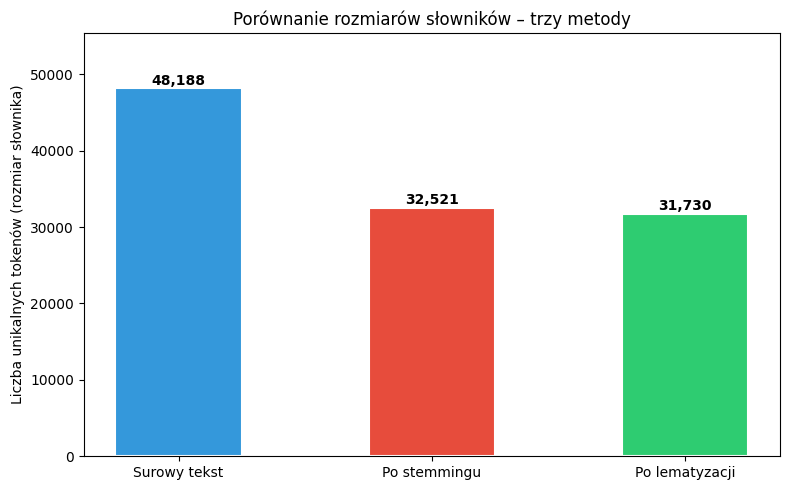

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
methods = ["Surowy tekst", "Po stemmingu", "Po lematyzacji"]
sizes   = [len(vocab_raw), len(vocab_stem), len(vocab_lemma)]
colors  = ["#3498db", "#e74c3c", "#2ecc71"]
bars = ax.bar(methods, sizes, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Liczba unikalnych tokenów (rozmiar słownika)")
ax.set_title("Porównanie rozmiarów słowników – trzy metody")
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.savefig("vocab_comparison.png", dpi=120)
plt.show()

In [ ]:
MODEL_NAME = "allegro/herbert-base-cased"
print(f"Ładowanie modelu: {MODEL_NAME}")

tokenizer_herbert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_herbert     = AutoModel.from_pretrained(MODEL_NAME).to(device)
model_herbert.eval()

print("HerBERT gotowy.")

def get_embedding(text: str) -> np.ndarray:
    inputs = tokenizer_herbert(
        text, return_tensors="pt", truncation=True, max_length=512, padding=True
    ).to(device)
    with torch.no_grad():
        outputs = model_herbert(**inputs)
    hidden = outputs.last_hidden_state           # (1, seq_len, hidden_size)
    mask   = inputs["attention_mask"].unsqueeze(-1).float()
    embedding = (hidden * mask).sum(1) / mask.sum(1)  # mean pooling
    return embedding.squeeze().cpu().numpy()

Ładowanie modelu: allegro/herbert-base-cased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 60544.50it/s]
BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HerBERT gotowy.


In [ ]:
N_SAMPLE = 200
pos = df_bin[df_bin["sentiment"] == "pozytywny"].sample(N_SAMPLE // 2, random_state=42)
neg = df_bin[df_bin["sentiment"] == "negatywny"].sample(N_SAMPLE // 2, random_state=42)
df_sample = pd.concat([pos, neg]).reset_index(drop=True)

print(f"Generowanie embeddingów dla {len(df_sample)} recenzji...")
embeddings = []
for i, text in enumerate(df_sample["text"]):
    embeddings.append(get_embedding(text))
    if (i + 1) % 50 == 0:
        print(f"   {i+1}/{len(df_sample)}")

embeddings = np.array(embeddings)
print(f"Embeddingi gotowe. Kształt macierzy: {embeddings.shape}")

Generowanie embeddingów dla 200 recenzji...
   50/200
   100/200
   150/200
   200/200
Embeddingi gotowe. Kształt macierzy: (200, 768)


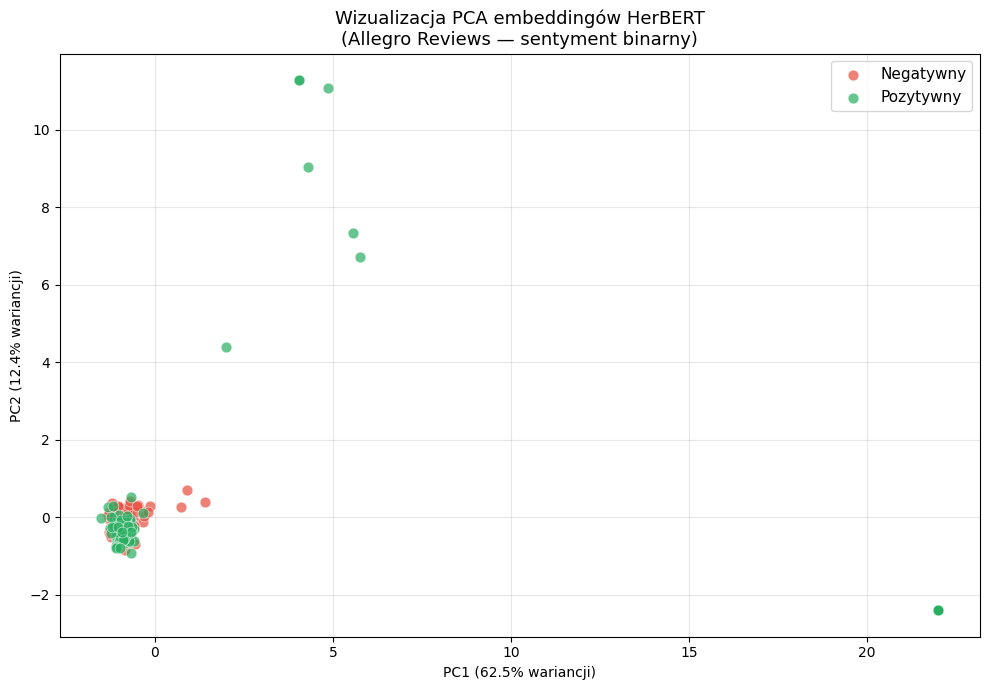

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

df_sample["pca_x"] = coords[:, 0]
df_sample["pca_y"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
colors_map = {"pozytywny": "#27ae60", "negatywny": "#e74c3c"}
for sentiment, group in df_sample.groupby("sentiment"):
    ax.scatter(
        group["pca_x"], group["pca_y"],
        c=colors_map[sentiment],
        label=sentiment.capitalize(),
        alpha=0.7, s=60, edgecolors="white", linewidth=0.5
    )
ax.set_title("Wizualizacja PCA embeddingów HerBERT\n(Allegro Reviews — sentyment binarny)", fontsize=13)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% wariancji)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("herbert_pca.png", dpi=120)
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

labels = (df_bin["sentiment"] == "pozytywny").astype(int).values
texts_raw   = df_bin["text"].tolist()
texts_stem  = df_bin["stemmed_text"].tolist()
texts_lemma = df_bin["lemma_text"].tolist()

In [ ]:
from sklearn.model_selection import train_test_split

results = {}

for method_name, texts in [
    ("Surowy tekst", texts_raw),
    ("Stemming",     texts_stem),
    ("Lematyzacja",  texts_lemma),
]:
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("clf",   LogisticRegression(max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[method_name] = acc
    print(f"\n{'='*50}")
    print(f"Metoda: {method_name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Negatywny", "Pozytywny"]))

labels_sample = (df_sample["sentiment"] == "pozytywny").astype(int).values
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    embeddings, labels_sample, test_size=0.2, random_state=42, stratify=labels_sample
)
clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_train_e, y_train_e)
y_pred_e = clf_bert.predict(X_test_e)
acc_bert = accuracy_score(y_test_e, y_pred_e)
results["HerBERT embeddingi"] = acc_bert
print(f"\n{'='*50}")
print(f"Metoda: HerBERT embeddingi")
print(f"Accuracy: {acc_bert:.4f}")
print(classification_report(y_test_e, y_pred_e, target_names=["Negatywny", "Pozytywny"]))


Metoda: Surowy tekst
Accuracy: 0.8787
              precision    recall  f1-score   support

   Negatywny       0.89      0.72      0.80       560
   Pozytywny       0.87      0.96      0.91      1114

    accuracy                           0.88      1674
   macro avg       0.88      0.84      0.86      1674
weighted avg       0.88      0.88      0.88      1674


Metoda: Stemming
Accuracy: 0.8566
              precision    recall  f1-score   support

   Negatywny       0.88      0.66      0.76       560
   Pozytywny       0.85      0.95      0.90      1114

    accuracy                           0.86      1674
   macro avg       0.86      0.81      0.83      1674
weighted avg       0.86      0.86      0.85      1674


Metoda: Lematyzacja
Accuracy: 0.8501
              precision    recall  f1-score   support

   Negatywny       0.87      0.65      0.74       560
   Pozytywny       0.84      0.95      0.89      1114

    accuracy                           0.85      1674
   macro avg    

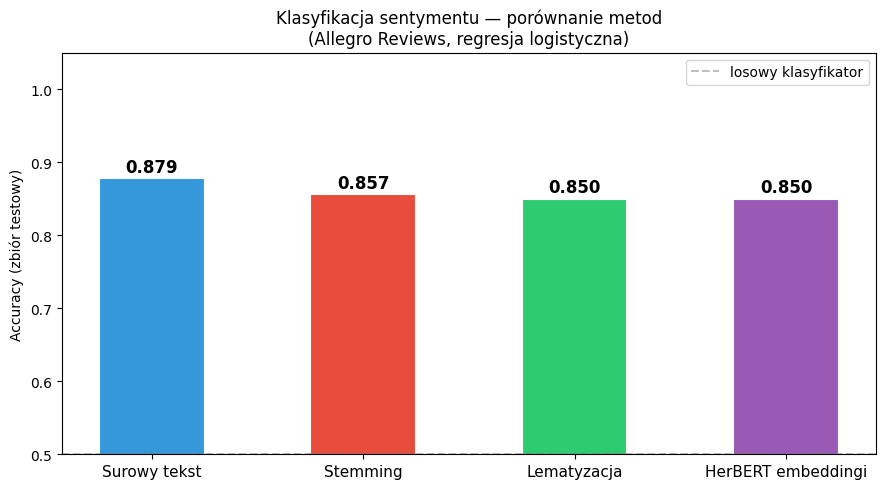

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
methods_list = list(results.keys())
acc_list     = list(results.values())
bar_colors   = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"]
bars = ax.bar(methods_list, acc_list, color=bar_colors, width=0.5,
              edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, acc_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("Accuracy (zbiór testowy)")
ax.set_title("Klasyfikacja sentymentu — porównanie metod\n(Allegro Reviews, regresja logistyczna)", fontsize=12)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="losowy klasyfikator")
ax.legend()
plt.xticks(fontsize=11)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=120)
plt.show()

In [ ]:
print("\nPodsumowanie wyników:")
for method, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {method:<25s}: {acc:.4f}")

print("Skrypt zakończony. Pliki zapisane: rating_distribution.png, "
      "vocab_comparison.png, herbert_pca.png, accuracy_comparison.png")


📊 Podsumowanie wyników:
  Surowy tekst             : 0.8787
  Stemming                 : 0.8566
  Lematyzacja              : 0.8501
  HerBERT embeddingi       : 0.8500
Skrypt zakończony. Pliki zapisane: rating_distribution.png, vocab_comparison.png, herbert_pca.png, accuracy_comparison.png
